In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Processed_Reviews (1).csv", encoding="ISO-8859-1")

In [3]:
X_text = df['lemmatized'].values
print(f"Text samples: {X_text[:2]}")

Text samples: ['product arrive time packaging great quality amazing'
 'product amaze love']


In [4]:
#Encode labels properly
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['label'])
print(f"\nLabel mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")
print(f"Class distribution: {pd.Series(y).value_counts().to_dict()}")


Label mapping: {'negative = 0': np.int64(0), 'positive = 1': np.int64(1)}
Class distribution: {1: 11, 0: 2}


In [5]:
tfidf_vect = TfidfVectorizer(
    max_features=100,  # Reduce features for small dataset
    stop_words='english',
    min_df=1
)
X = tfidf_vect.fit_transform(X_text)
print(f"Feature matrix shape: {X.shape}")


Feature matrix shape: (13, 47)


In [6]:
#Split with stratification (since we have imbalanced classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"  Class 0: {sum(y_train==0)}, Class 1: {sum(y_train==1)}")
print(f"Test set: {X_test.shape[0]} samples")
print(f"  Class 0: {sum(y_test==0)}, Class 1: {sum(y_test==1)}")

Training set: 9 samples
  Class 0: 1, Class 1: 8
Test set: 4 samples
  Class 0: 1, Class 1: 3


In [7]:
#Train models

# Naive Bayes
nb_clf = MultinomialNB()
nb_clf.fit(X_train, y_train)
nb_pred = nb_clf.predict(X_test)

# SVM
svm_clf = SVC(kernel='linear', random_state=42)
svm_clf.fit(X_train, y_train)
svm_pred = svm_clf.predict(X_test)

In [8]:
# 7. Evaluate models
print("NAIVE BAYES RESULTS")

nb_accuracy = accuracy_score(y_test, nb_pred)
nb_error_rate = 1 - nb_accuracy
nb_cm = confusion_matrix(y_test, nb_pred)

print(f"Accuracy: {nb_accuracy:.4f}")
print(f"Error Rate: {nb_error_rate:.4f}")
print("\nConfusion Matrix:")
print(nb_cm)
print("\nClassification Report:")
print(classification_report(y_test, nb_pred, target_names=label_encoder.classes_))

print("SVM RESULTS")

svm_accuracy = accuracy_score(y_test, svm_pred)
svm_error_rate = 1 - svm_accuracy
svm_cm = confusion_matrix(y_test, svm_pred)

print(f"Accuracy: {svm_accuracy:.4f}")
print(f"Error Rate: {svm_error_rate:.4f}")
print("\nConfusion Matrix:")
print(svm_cm)
print("\nClassification Report:")
print(classification_report(y_test, svm_pred, target_names=label_encoder.classes_))

NAIVE BAYES RESULTS
Accuracy: 0.7500
Error Rate: 0.2500

Confusion Matrix:
[[0 1]
 [0 3]]

Classification Report:
              precision    recall  f1-score   support

negative = 0       0.00      0.00      0.00         1
positive = 1       0.75      1.00      0.86         3

    accuracy                           0.75         4
   macro avg       0.38      0.50      0.43         4
weighted avg       0.56      0.75      0.64         4

SVM RESULTS
Accuracy: 0.7500
Error Rate: 0.2500

Confusion Matrix:
[[0 1]
 [0 3]]

Classification Report:
              precision    recall  f1-score   support

negative = 0       0.00      0.00      0.00         1
positive = 1       0.75      1.00      0.86         3

    accuracy                           0.75         4
   macro avg       0.38      0.50      0.43         4
weighted avg       0.56      0.75      0.64         4



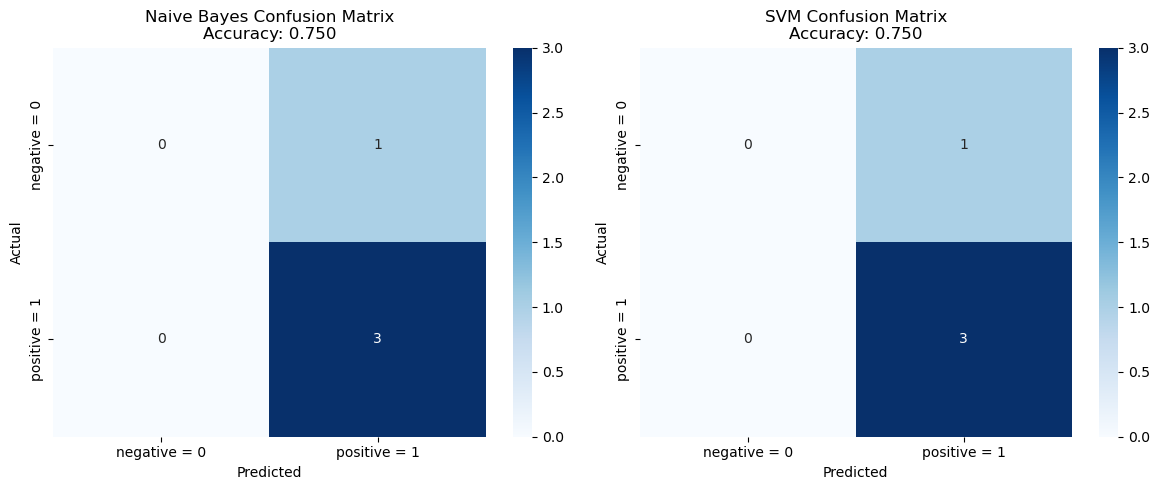

In [9]:
#Visualize results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Naive Bayes
sns.heatmap(nb_cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
ax1.set_title(f'Naive Bayes Confusion Matrix\nAccuracy: {nb_accuracy:.3f}')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# SVM
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
ax2.set_title(f'SVM Confusion Matrix\nAccuracy: {svm_accuracy:.3f}')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()